# 🚦 Automated Traffic Flow Counting — Frankfurt am Main
**PBL Project | OTH Amberg-Weiden**

This notebook covers all 3 tasks:
- **Task 1:** Daily profiles per vehicle category + peak identification
- **Task 2:** Weekly heatmaps (weekday × hour) across all locations
- **Task 3:** Site comparison — most congested overall, each Monday, each Sunday

---
### 📁 How to set up your data
Place all 4 unzipped folders into a folder called `data/` next to this notebook:
```
data/
  DZwEI 16.09-23.09/
  DZwEI 24.09-29.09/
  DZwEI 30.09-07.10/
  DZwEI 14.10-22.10/
```

## 0 — Setup & Data Loading

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Step 2: Install missing libraries ───────────────────────────────────────
!pip install openpyxl seaborn --quiet

# ── Step 3: Find the exact path to your DZwEI folders ───────────────────────
import os

def find_dzwei_folders(start='/content/drive/MyDrive'):
    """Search Drive for any folder starting with 'DZwEI' and print its path."""
    print('🔍 Searching for DZwEI folders in your Drive...\n')
    found = []
    for root, dirs, files in os.walk(start):
        for d in dirs:
            if d.startswith('DZwEI') or d.startswith('DZwEl'):
                found.append(os.path.join(root, d))
        # Don't recurse too deep
        depth = root.replace(start, '').count(os.sep)
        if depth >= 3:
            dirs.clear()
    if found:
        parent = os.path.dirname(found[0])
        print(f'✅ Found {len(found)} DZwEI folder(s)!')
        print(f'   Parent folder: {parent}')
        print(f'\n   Folders:')
        for f in sorted(found):
            print(f'     📁 {os.path.basename(f)}')
        print(f'\n👉 Copy this path into DATA_ROOT below:\n   "{parent}"')
    else:
        print('❌ No DZwEI folders found. Listing top-level MyDrive contents:')
        for item in sorted(os.listdir(start)):
            print(f'   {item}')
    return parent if found else None

detected_path = find_dzwei_folders()


Mounted at /content/drive
🔍 Searching for DZwEI folders in your Drive...

✅ Found 6 DZwEI folder(s)!
   Parent folder: /content/drive/MyDrive/python

   Folders:
     📁 DZwEI 08.10-13.10
     📁 DZwEI 09.09-15.09
     📁 DZwEI 14.10-22.10
     📁 DZwEI 16.09-23.09
     📁 DZwEI 24.09-29.09
     📁 DZwEI 30.09-07.10

👉 Copy this path into DATA_ROOT below:
   "/content/drive/MyDrive/python"


In [2]:
import os
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from openpyxl import load_workbook

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Path to your data folder ─────────────────────────────────────────────────
# ── Path to your data folders in Google Drive ───────────────────────────────
# This uses the path auto-detected in the cell above.
# If it's wrong, paste the correct path manually here:
DATA_ROOT = detected_path  # e.g. '/content/drive/MyDrive/python'

# ── Vehicle sheets available in every Excel file ─────────────────────────────
VEHICLE_SHEETS = [
    'Gesamt-Kfz',       # All vehicles combined
    'Pkw',              # Passenger cars
    'Lkw',              # Trucks
    'Bus',              # Buses
    'Kraftrad',         # Motorcycles
    'Lieferwagen',      # Delivery vans
    'Sattelzug',        # Semi-trucks / articulated lorries
    'SV >3.5t',         # Heavy vehicles (aggregated)
    'LV <3.5t',         # Light vehicles (aggregated)
]

VEHICLE_LABELS = {
    'Gesamt-Kfz' : 'All Vehicles',
    'Pkw'        : 'Cars (Pkw)',
    'Lkw'        : 'Trucks (Lkw)',
    'Bus'        : 'Buses',
    'Kraftrad'   : 'Motorcycles',
    'Lieferwagen': 'Delivery Vans',
    'Sattelzug'  : 'Semi-trucks',
    'SV >3.5t'   : 'Heavy (>3.5t)',
    'LV <3.5t'   : 'Light (<3.5t)',
}

# ── Output directory (plots saved here) ─────────────────────────────────────
OUTPUT_DIR = os.path.join(DATA_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Libraries loaded successfully')
print(f'   DATA_ROOT  : {DATA_ROOT}')
print(f'   OUTPUT_DIR : {OUTPUT_DIR}')

✅ Libraries loaded successfully
   DATA_ROOT  : /content/drive/MyDrive/python
   OUTPUT_DIR : /content/drive/MyDrive/python/outputs


In [3]:
def clean_location_name(raw: str) -> str:
    """Fix URL-encoded German chars and strip GPS coords from folder names."""
    import re
    # Fix URL-encoded chars FIRST (#U00dfe = 'ße', not just 'ß')
    cleaned = raw.replace('#U00dfe', 'ße').replace('#U00f6', 'ö').replace('#U00e4', 'ä').replace('#U00fc', 'ü')
    # Then strip trailing GPS like ' 50.1270654,8.6893089'
    cleaned = re.sub(r'\s+\d{2}\.\d+,\d+\.\d+$', '', cleaned).strip()
    return cleaned


def parse_start_date(date_str: str) -> datetime.date:
    """
    Parse date strings like 'Mon, 16. Sep 2024' or 'Tue, 24. Sep 2024'
    """
    import re
    match = re.search(r'(\d+)\.\s*(\w+)\s*(\d{4})', date_str)
    if not match:
        raise ValueError(f'Cannot parse date: {date_str}')
    day, month_str, year = match.groups()
    month_map = {
        'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
        'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
    }
    return datetime.date(int(year), month_map[month_str], int(day))


def load_sheet(path: str, sheet_name: str, start_date: datetime.date) -> pd.DataFrame:
    """
    Load one vehicle-type sheet from an Excel file.
    Returns a DataFrame with columns: [datetime, interval_count]
    Each file stores 96 rows per day (15-min intervals) back-to-back.
    Column index 5 = 'Intervall' = total count for that 15-min slot.
    """
    wb = load_workbook(path, read_only=True, data_only=True)
    if sheet_name not in wb.sheetnames:
        wb.close()
        return pd.DataFrame()
    ws = wb[sheet_name]
    raw = list(ws.iter_rows(values_only=True))
    wb.close()

    # Data rows start at index 12 (row 13 in Excel, 1-indexed)
    data_rows = [r for r in raw[12:] if isinstance(r[0], datetime.time)]

    records = []
    INTERVALS_PER_DAY = 96  # 24h × 4 per hour
    for idx, row in enumerate(data_rows):
        day_offset = idx // INTERVALS_PER_DAY
        t = row[0]  # datetime.time
        count = row[5] if row[5] is not None else 0  # 'Intervall' column
        dt = datetime.datetime.combine(
            start_date + datetime.timedelta(days=day_offset), t
        )
        records.append({'datetime': dt, 'count': int(count) if isinstance(count, (int, float)) else 0})

    return pd.DataFrame(records)


def load_all_data(data_root: str) -> pd.DataFrame:
    """
    Walk through all week folders → location subfolders → xlsx files.
    Returns a single master DataFrame with columns:
    [location, vehicle_type, datetime, count, hour, weekday, weekday_name, date]
    """
    all_dfs = []

    for week_dir in sorted(os.listdir(data_root)):
        week_path = os.path.join(data_root, week_dir)
        if not os.path.isdir(week_path):
            continue

        for loc_dir in sorted(os.listdir(week_path)):
            loc_path = os.path.join(week_path, loc_dir)
            if not os.path.isdir(loc_path):
                continue
            if loc_dir.lower() == 'parking':
                continue

            location = clean_location_name(loc_dir)

            # Find the xlsx file
            xlsx_files = [f for f in os.listdir(loc_path) if f.endswith('.xlsx')]
            if not xlsx_files:
                continue
            xlsx_path = os.path.join(loc_path, xlsx_files[0])

            # Get start date from Gesamt-Kfz sheet metadata (row 3, col 2)
            try:
                wb = load_workbook(xlsx_path, read_only=True, data_only=True)
                ws = wb['Gesamt-Kfz']
                rows = list(ws.iter_rows(max_row=4, values_only=True))
                wb.close()
                start_date = parse_start_date(str(rows[2][2]))
            except Exception as e:
                print(f'  ⚠️ Could not read start date from {xlsx_path}: {e}')
                continue

            print(f'  Loading: {location} | start={start_date} | {week_dir}')

            # Load each vehicle sheet
            for vtype in VEHICLE_SHEETS:
                df = load_sheet(xlsx_path, vtype, start_date)
                if df.empty:
                    continue
                df['location'] = location
                df['vehicle_type'] = vtype
                df['week'] = week_dir
                all_dfs.append(df)

    if not all_dfs:
        raise FileNotFoundError(f'No data found in {data_root}. Check DATA_ROOT path.')

    master = pd.concat(all_dfs, ignore_index=True)
    master['datetime'] = pd.to_datetime(master['datetime'])
    master['hour'] = master['datetime'].dt.hour
    master['weekday'] = master['datetime'].dt.weekday          # 0=Mon … 6=Sun
    master['weekday_name'] = master['datetime'].dt.strftime('%A')
    master['date'] = master['datetime'].dt.date
    master['count'] = pd.to_numeric(master['count'], errors='coerce').fillna(0).astype(int)

    return master


print('✅ Helper functions defined')

✅ Helper functions defined


In [4]:
print('📂 Loading all data — this may take ~30 seconds...')
df = load_all_data(DATA_ROOT)

print(f'\n✅ Master DataFrame loaded!')
print(f'   Rows      : {len(df):,}')
print(f'   Locations : {df.location.nunique()} → {sorted(df.location.unique())}')
print(f'   Date range: {df.date.min()} → {df.date.max()}')
print(f'   Vehicles  : {sorted(df.vehicle_type.unique())}')
df.head()

📂 Loading all data — this may take ~30 seconds...
  Loading: Glauburgstraße | start=2024-10-08 | DZwEI 08.10-13.10
  Loading: Hanauer Landstraße | start=2024-10-08 | DZwEI 08.10-13.10
  Loading: Hanauer Landstraße | start=2024-10-08 | DZwEI 08.10-13.10
  Loading: Töngesgasse | start=2024-10-08 | DZwEI 08.10-13.10
  Loading: B44 | start=2024-09-09 | DZwEI 09.09-15.09
  Loading: Habsburgerallee 59 | start=2024-09-09 | DZwEI 09.09-15.09
  Loading: Heiligkreuzgasse | start=2024-09-09 | DZwEI 09.09-15.09
  Loading: Mainzer Landstraße 32 | start=2024-09-09 | DZwEI 09.09-15.09
  Loading: Glauburgstraße | start=2024-10-14 | DZwEI 14.10-22.10
  Loading: Hanauer Landstraße | start=2024-10-14 | DZwEI 14.10-22.10
  Loading: Hanauer Landstraße | start=2024-10-14 | DZwEI 14.10-22.10
  Loading: Töngesgasse | start=2024-10-14 | DZwEI 14.10-22.10
  Loading: B44 | start=2024-09-16 | DZwEI 16.09-23.09
  Loading: Habsburgerallee 59 | start=2024-09-16 | DZwEI 16.09-23.09
  Loading: Heiligkreuzgasse | sta

,datetime,count,location,vehicle_type,week,hour,weekday,weekday_name,date
0,2024-10-08 00:00:00,0,Glauburgstraße,Gesamt-Kfz,DZwEI 08.10-13.10,0,1,Tuesday,2024-10-08
1,2024-10-08 00:15:00,0,Glauburgstraße,Gesamt-Kfz,DZwEI 08.10-13.10,0,1,Tuesday,2024-10-08
2,2024-10-08 00:30:00,0,Glauburgstraße,Gesamt-Kfz,DZwEI 08.10-13.10,0,1,Tuesday,2024-10-08
3,2024-10-08 00:45:00,0,Glauburgstraße,Gesamt-Kfz,DZwEI 08.10-13.10,0,1,Tuesday,2024-10-08
4,2024-10-08 01:00:00,0,Glauburgstraße,Gesamt-Kfz,DZwEI 08.10-13.10,1,1,Tuesday,2024-10-08


In [5]:
# ── Step 3: Verify folders are visible ──────────────────────────────────────
import os
print('Folders found in DATA_ROOT:')
for item in sorted(os.listdir(DATA_ROOT)):
    full = os.path.join(DATA_ROOT, item)
    if os.path.isdir(full):
        sub = [s for s in os.listdir(full) if os.path.isdir(os.path.join(full, s))]
        print(f'  📁 {item}  →  {len(sub)} location(s): {sub}')

print(f'\nPlots will be saved to: {OUTPUT_DIR}')

# ── Note: extra folders (DZwEI 08.10-13.10, DZwEI 09.09-15.09) ────────────
# These were not in the original 4 ZIPs you uploaded but ARE in your Drive.
# The notebook will automatically include them — no changes needed!
print('\n✅ All folders above will be loaded automatically (including any extra weeks)')

Folders found in DATA_ROOT:
  📁 DZwEI 08.10-13.10  →  4 location(s): ['Töngesgasse 50.1135489,8.6857431', 'Glauburgstraße 50.1270654,8.6893089', 'Hanauer Landstraße 50.1125629,8.7039647', 'Hanauer Landstraße 50.1134021,8.6969654']
  📁 DZwEI 09.09-15.09  →  4 location(s): ['Habsburgerallee 59', 'B44', 'Heiligkreuzgasse', 'Mainzer Landstraße 32']
  📁 DZwEI 14.10-22.10  →  4 location(s): ['Hanauer Landstraße 50.1125629,8.7039647', 'Töngesgasse 50.1135489,8.6857431', 'Glauburgstraße 50.1270654,8.6893089', 'Hanauer Landstraße 50.1134021,8.6969654']
  📁 DZwEI 16.09-23.09  →  4 location(s): ['Heiligkreuzgasse', 'Habsburgerallee 59', 'B44', 'Mainzer Landstraße 32']
  📁 DZwEI 24.09-29.09  →  4 location(s): ['Mercatorstr. 37', 'Friedberger Tor', 'Max Horkheimer Str. 2', 'Richard Wagner Straße']
  📁 DZwEI 30.09-07.10  →  4 location(s): ['Mercatorstr. 37', 'Richard Wagner Straße', 'Max Horkheimer Str. 2', 'Friedberger Tor']
  📁 outputs  →  0 location(s): []

Plots will be saved to: /content/driv

---
## Task 1 — Daily Profiles per Vehicle Category & Peak Identification

**Goal:** Show how traffic volume evolves over a 24-hour period for each vehicle type, averaged across all available days. Annotate morning and evening peaks.

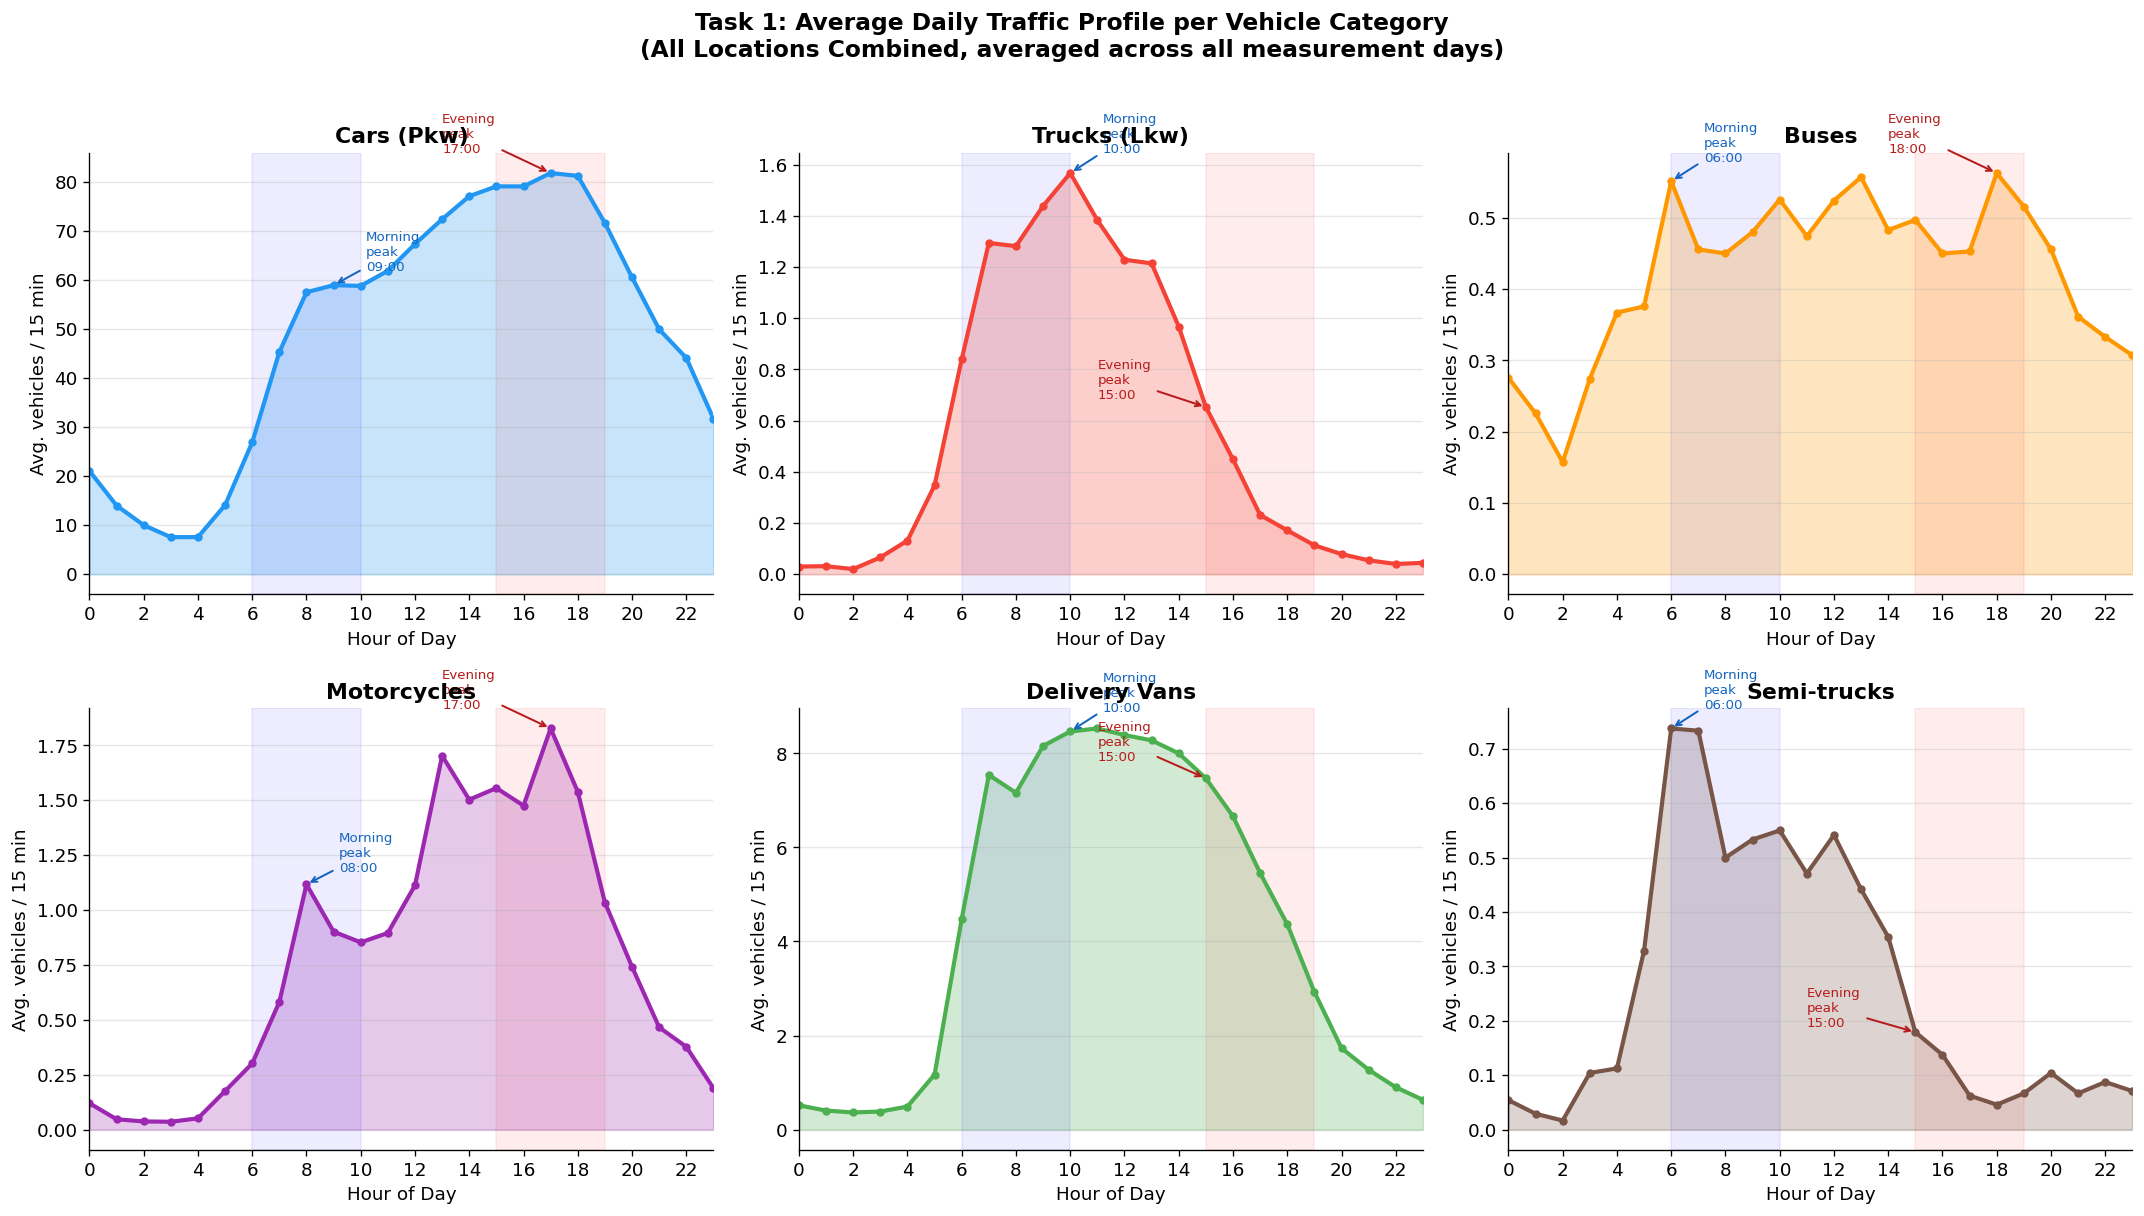

💾 Saved: task1_daily_profiles.png


In [6]:
# ── Task 1-A: Average daily profile per vehicle type (all locations combined) ──

# Exclude 'Gesamt-Kfz', 'SV >3.5t', 'LV <3.5t' (aggregates) for the per-type breakdown
INDIVIDUAL_TYPES = ['Pkw', 'Lkw', 'Bus', 'Kraftrad', 'Lieferwagen', 'Sattelzug']
COLORS = ['#2196F3', '#F44336', '#FF9800', '#9C27B0', '#4CAF50', '#795548']

df_ind = df[df['vehicle_type'].isin(INDIVIDUAL_TYPES)].copy()

# Average 15-min count per hour × vehicle type (across all days & locations)
hourly_by_type = (
    df_ind
    .groupby(['vehicle_type', 'hour'])['count']
    .mean()
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()
fig.suptitle('Task 1: Average Daily Traffic Profile per Vehicle Category\n(All Locations Combined, averaged across all measurement days)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, vtype, color in zip(axes, INDIVIDUAL_TYPES, COLORS):
    sub = hourly_by_type[hourly_by_type['vehicle_type'] == vtype]
    ax.fill_between(sub['hour'], sub['count'], alpha=0.25, color=color)
    ax.plot(sub['hour'], sub['count'], color=color, linewidth=2.5, marker='o', markersize=4)

    # Identify morning (6-10) and evening (15-19) peaks
    morn = sub[sub['hour'].between(6, 10)]
    eve  = sub[sub['hour'].between(15, 19)]
    if not morn.empty:
        pk_h = morn.loc[morn['count'].idxmax(), 'hour']
        pk_v = morn['count'].max()
        ax.annotate(f'Morning\npeak\n{int(pk_h):02d}:00',
                    xy=(pk_h, pk_v), xytext=(pk_h + 1.2, pk_v * 1.05),
                    fontsize=8, color='#1565C0',
                    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.2))
    if not eve.empty:
        pk_h = eve.loc[eve['count'].idxmax(), 'hour']
        pk_v = eve['count'].max()
        ax.annotate(f'Evening\npeak\n{int(pk_h):02d}:00',
                    xy=(pk_h, pk_v), xytext=(pk_h - 4, pk_v * 1.05),
                    fontsize=8, color='#B71C1C',
                    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

    # Shade peak windows
    ax.axvspan(6, 10, alpha=0.07, color='blue', label='Morning window (6-10h)')
    ax.axvspan(15, 19, alpha=0.07, color='red', label='Evening window (15-19h)')

    ax.set_title(VEHICLE_LABELS[vtype], fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg. vehicles / 15 min')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(0, 23)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task1_daily_profiles.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task1_daily_profiles.png')

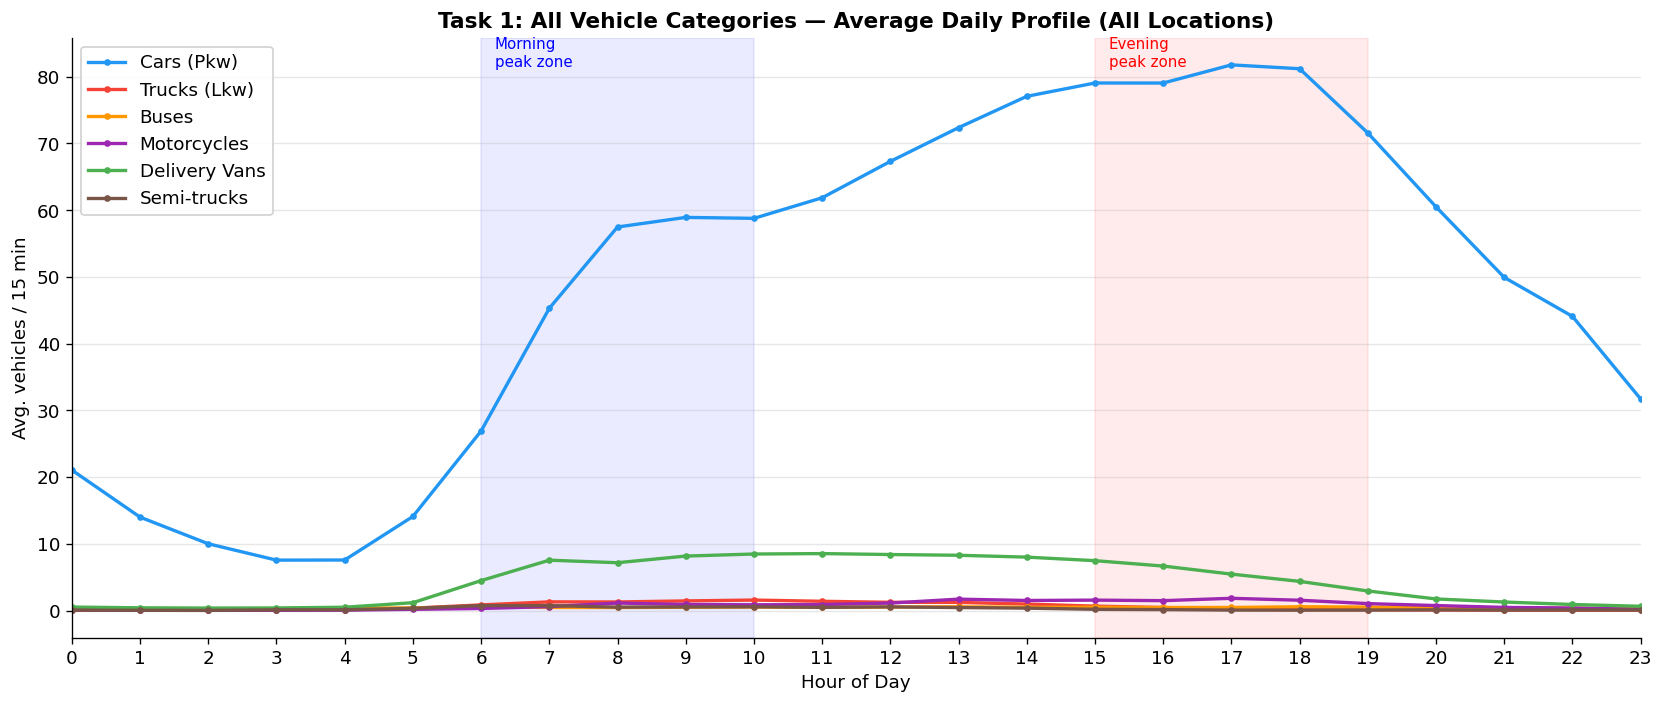

💾 Saved: task1_combined_overview.png


In [7]:
# ── Task 1-B: Combined overview — all vehicle types on one chart ───────────────

fig, ax = plt.subplots(figsize=(14, 6))

for vtype, color in zip(INDIVIDUAL_TYPES, COLORS):
    sub = hourly_by_type[hourly_by_type['vehicle_type'] == vtype]
    ax.plot(sub['hour'], sub['count'], color=color, linewidth=2,
            label=VEHICLE_LABELS[vtype], marker='o', markersize=3)

ax.axvspan(6, 10, alpha=0.08, color='blue')
ax.axvspan(15, 19, alpha=0.08, color='red')
ax.text(6.2, ax.get_ylim()[1] * 0.95, 'Morning\npeak zone', color='blue', fontsize=9)
ax.text(15.2, ax.get_ylim()[1] * 0.95, 'Evening\npeak zone', color='red', fontsize=9)

ax.set_title('Task 1: All Vehicle Categories — Average Daily Profile (All Locations)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg. vehicles / 15 min')
ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task1_combined_overview.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task1_combined_overview.png')

In [8]:
# ── Task 1-C: Peak summary table ──────────────────────────────────────────────

peak_records = []
for vtype in INDIVIDUAL_TYPES:
    sub = hourly_by_type[hourly_by_type['vehicle_type'] == vtype].set_index('hour')
    daily_peak_h  = sub['count'].idxmax()
    daily_peak_v  = sub['count'].max()
    morn_peak_h   = sub.loc[6:10, 'count'].idxmax()
    morn_peak_v   = sub.loc[6:10, 'count'].max()
    eve_peak_h    = sub.loc[15:19, 'count'].idxmax()
    eve_peak_v    = sub.loc[15:19, 'count'].max()
    night_avg     = sub.loc[list(range(22, 24)) + list(range(0, 6)), 'count'].mean()
    peak_records.append({
        'Vehicle Type'         : VEHICLE_LABELS[vtype],
        'Morning Peak Hour'    : f'{int(morn_peak_h):02d}:00',
        'Morning Peak (avg/15min)': f'{morn_peak_v:.1f}',
        'Evening Peak Hour'    : f'{int(eve_peak_h):02d}:00',
        'Evening Peak (avg/15min)': f'{eve_peak_v:.1f}',
        'Daily Peak Hour'      : f'{int(daily_peak_h):02d}:00',
        'Night Avg (avg/15min)': f'{night_avg:.1f}',
    })

peak_df = pd.DataFrame(peak_records).set_index('Vehicle Type')
print('\n📊 Peak Summary Table (averaged across all locations & days):')
peak_df


📊 Peak Summary Table (averaged across all locations & days):


,Morning Peak Hour,Morning Peak (avg/15min),Evening Peak Hour,Evening Peak (avg/15min),Daily Peak Hour,Night Avg (avg/15min)
Vehicle Type,,,,,,
Cars (Pkw),09:00,58.9,17:00,81.8,17:00,18.8
Trucks (Lkw),10:00,1.6,15:00,0.7,10:00,0.1
Buses,06:00,0.6,18:00,0.6,18:00,0.3
Motorcycles,08:00,1.1,17:00,1.8,17:00,0.1
Delivery Vans,10:00,8.5,15:00,7.5,11:00,0.6
Semi-trucks,06:00,0.7,15:00,0.2,06:00,0.1


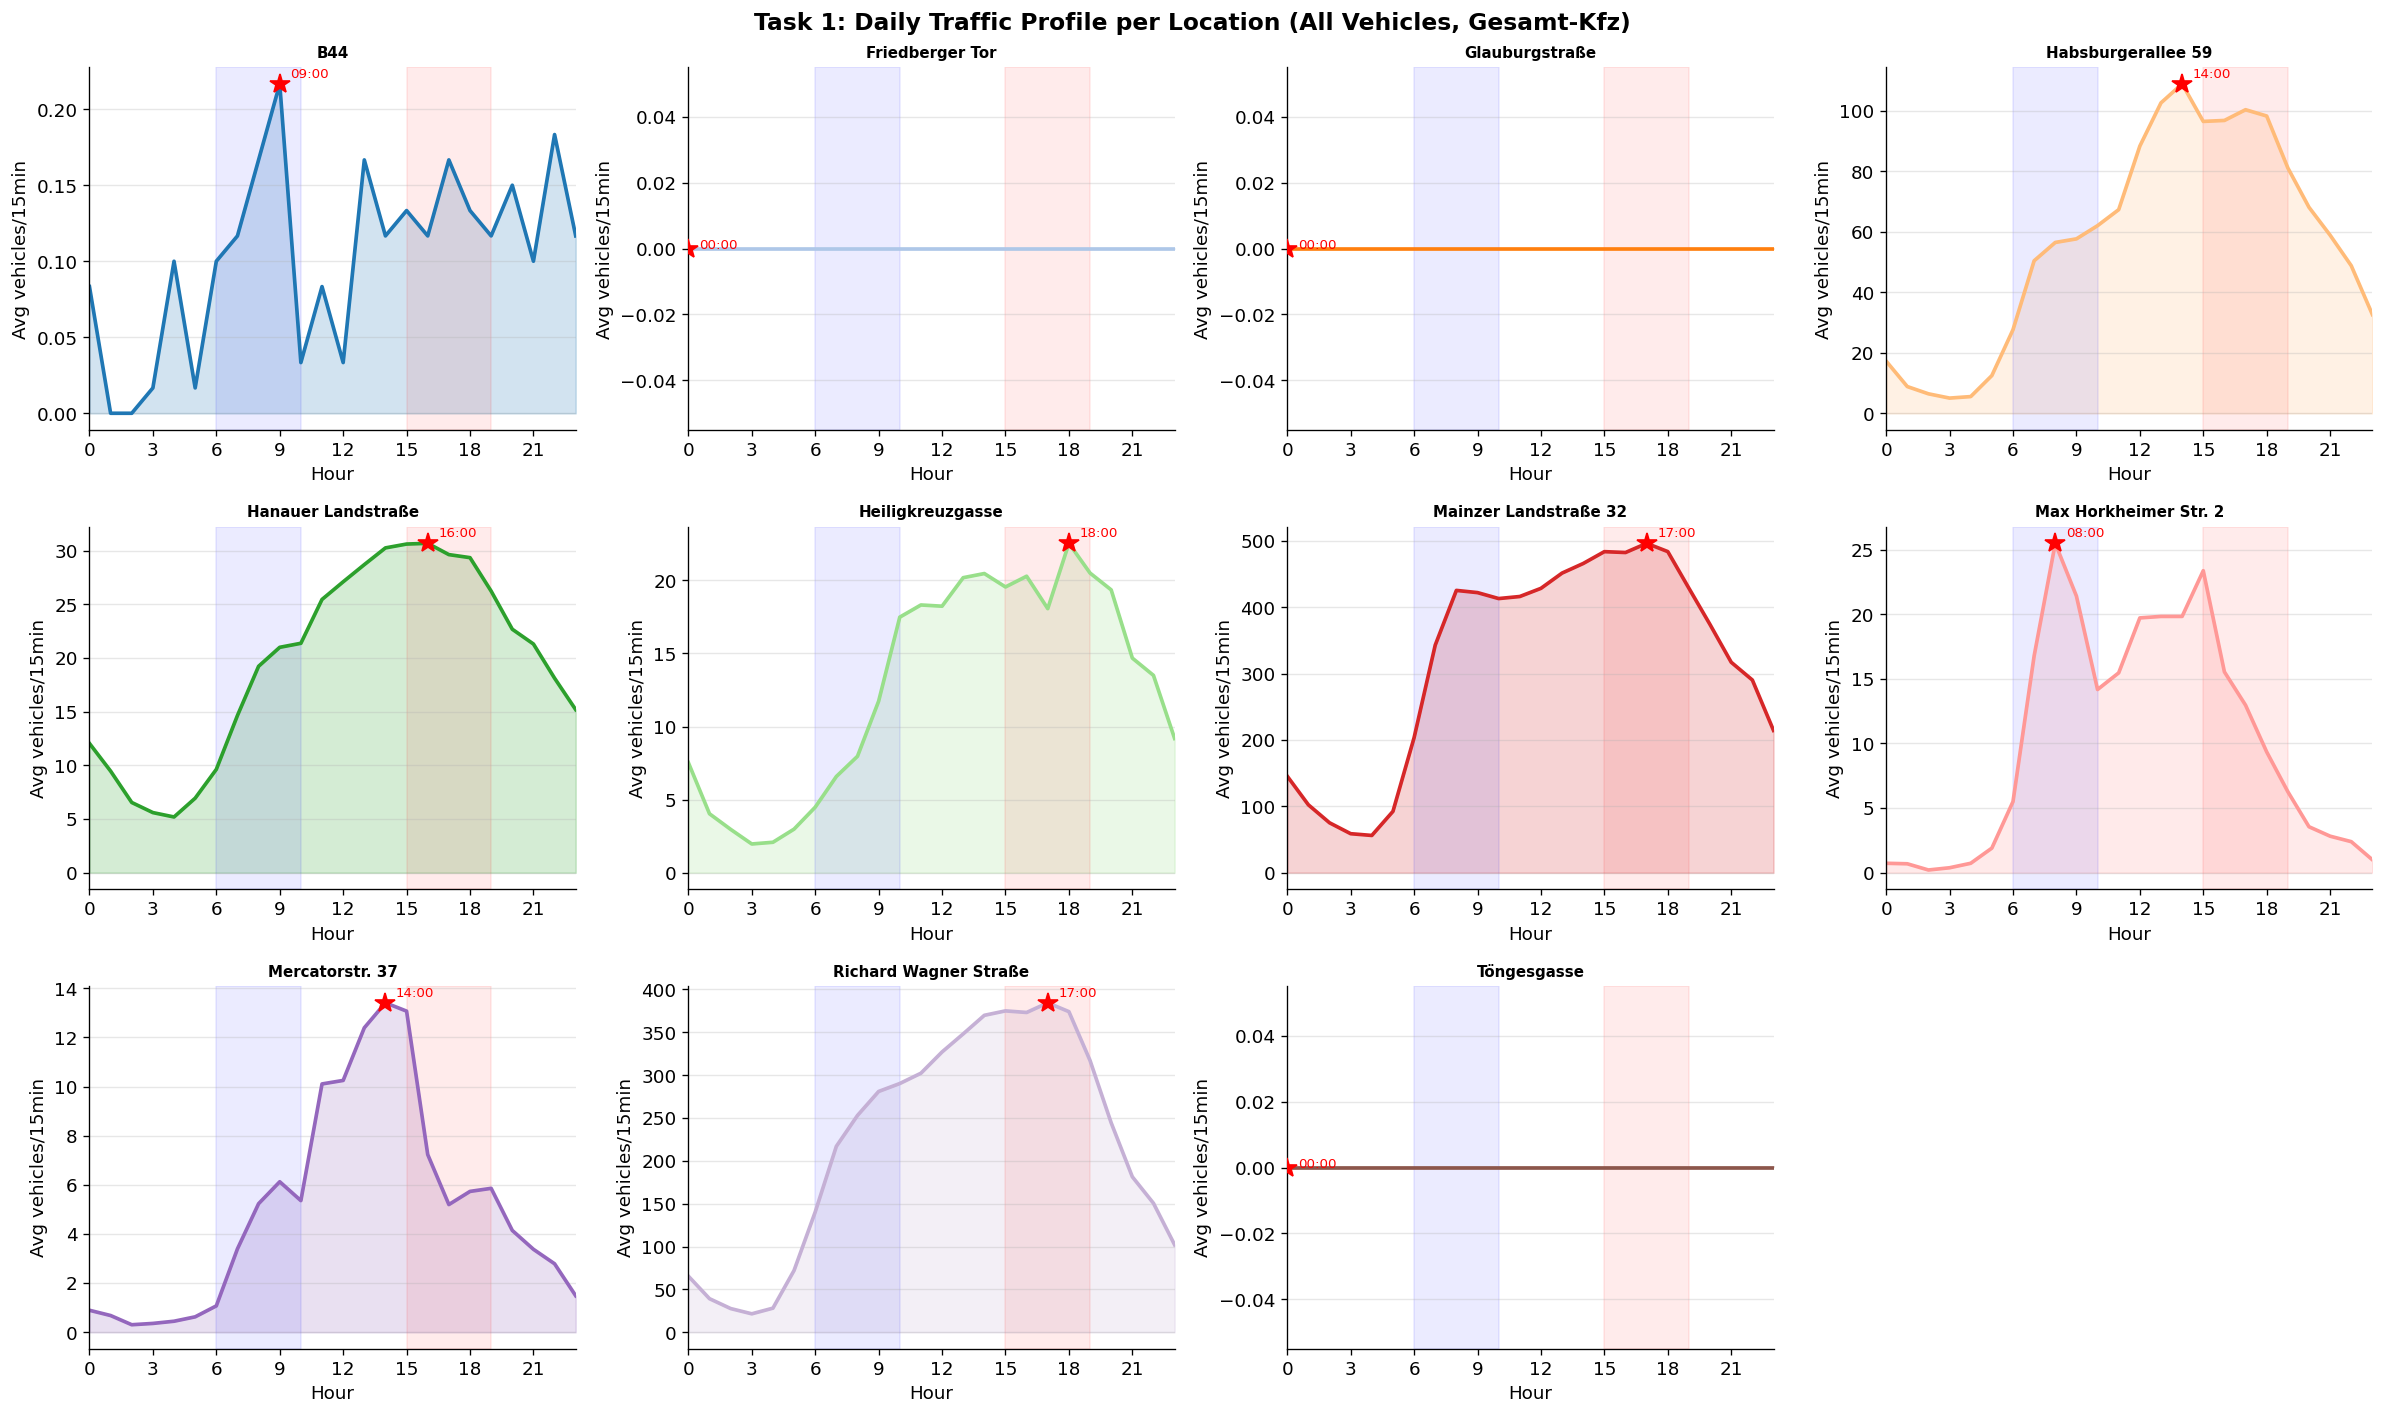

💾 Saved: task1_per_location_profiles.png


In [9]:
# ── Task 1-D: Per-location daily profiles (Gesamt-Kfz only) ──────────────────

df_total = df[df['vehicle_type'] == 'Gesamt-Kfz'].copy()
locations = sorted(df_total['location'].unique())
n_locs = len(locations)
cols = 4
rows_n = (n_locs + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(20, rows_n * 4), sharey=False)
axes = axes.flatten()
fig.suptitle('Task 1: Daily Traffic Profile per Location (All Vehicles, Gesamt-Kfz)',
             fontsize=14, fontweight='bold')

palette = plt.cm.tab20.colors

for i, loc in enumerate(locations):
    ax = axes[i]
    sub = df_total[df_total['location'] == loc]
    hourly = sub.groupby('hour')['count'].mean()

    color = palette[i % len(palette)]
    ax.fill_between(hourly.index, hourly.values, alpha=0.2, color=color)
    ax.plot(hourly.index, hourly.values, color=color, linewidth=2.2)

    ax.axvspan(6, 10, alpha=0.08, color='blue')
    ax.axvspan(15, 19, alpha=0.08, color='red')

    # Mark absolute peak
    pk_h = hourly.idxmax()
    pk_v = hourly.max()
    ax.plot(pk_h, pk_v, 'r*', markersize=12, zorder=5)
    ax.annotate(f'{int(pk_h):02d}:00', xy=(pk_h, pk_v), xytext=(pk_h + 0.5, pk_v * 1.02),
                fontsize=8, color='red')

    ax.set_title(loc, fontweight='bold', fontsize=9)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Avg vehicles/15min')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.grid(axis='y', alpha=0.3)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task1_per_location_profiles.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task1_per_location_profiles.png')

---
## Task 2 — Weekly Heatmaps (Weekday × Hour)

**Goal:** Visualize how traffic varies by hour of day AND day of week using heatmaps. Identify weekday vs weekend patterns and any unusual peaks.

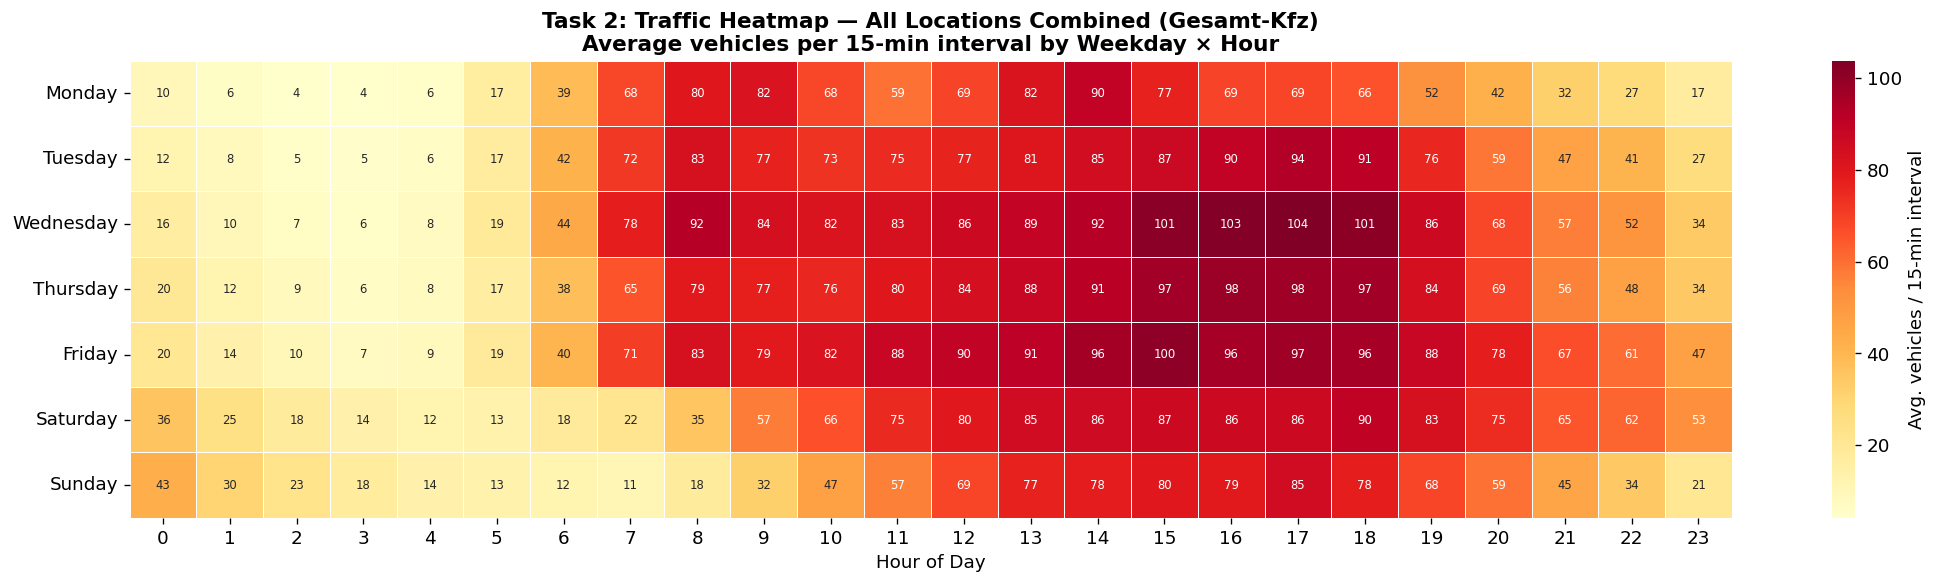

💾 Saved: task2_heatmap_global.png


In [10]:
# ── Task 2-A: Global heatmap — all locations combined (Gesamt-Kfz) ───────────

DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df_total = df[df['vehicle_type'] == 'Gesamt-Kfz'].copy()

# Average count per (weekday, hour)
hmap_data = (
    df_total
    .groupby(['weekday_name', 'hour'])['count']
    .mean()
    .reset_index()
    .pivot(index='weekday_name', columns='hour', values='count')
    .reindex(DAY_ORDER)
)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    hmap_data,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Avg. vehicles / 15-min interval'}
)
ax.set_title('Task 2: Traffic Heatmap — All Locations Combined (Gesamt-Kfz)\n'
             'Average vehicles per 15-min interval by Weekday × Hour',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_heatmap_global.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task2_heatmap_global.png')

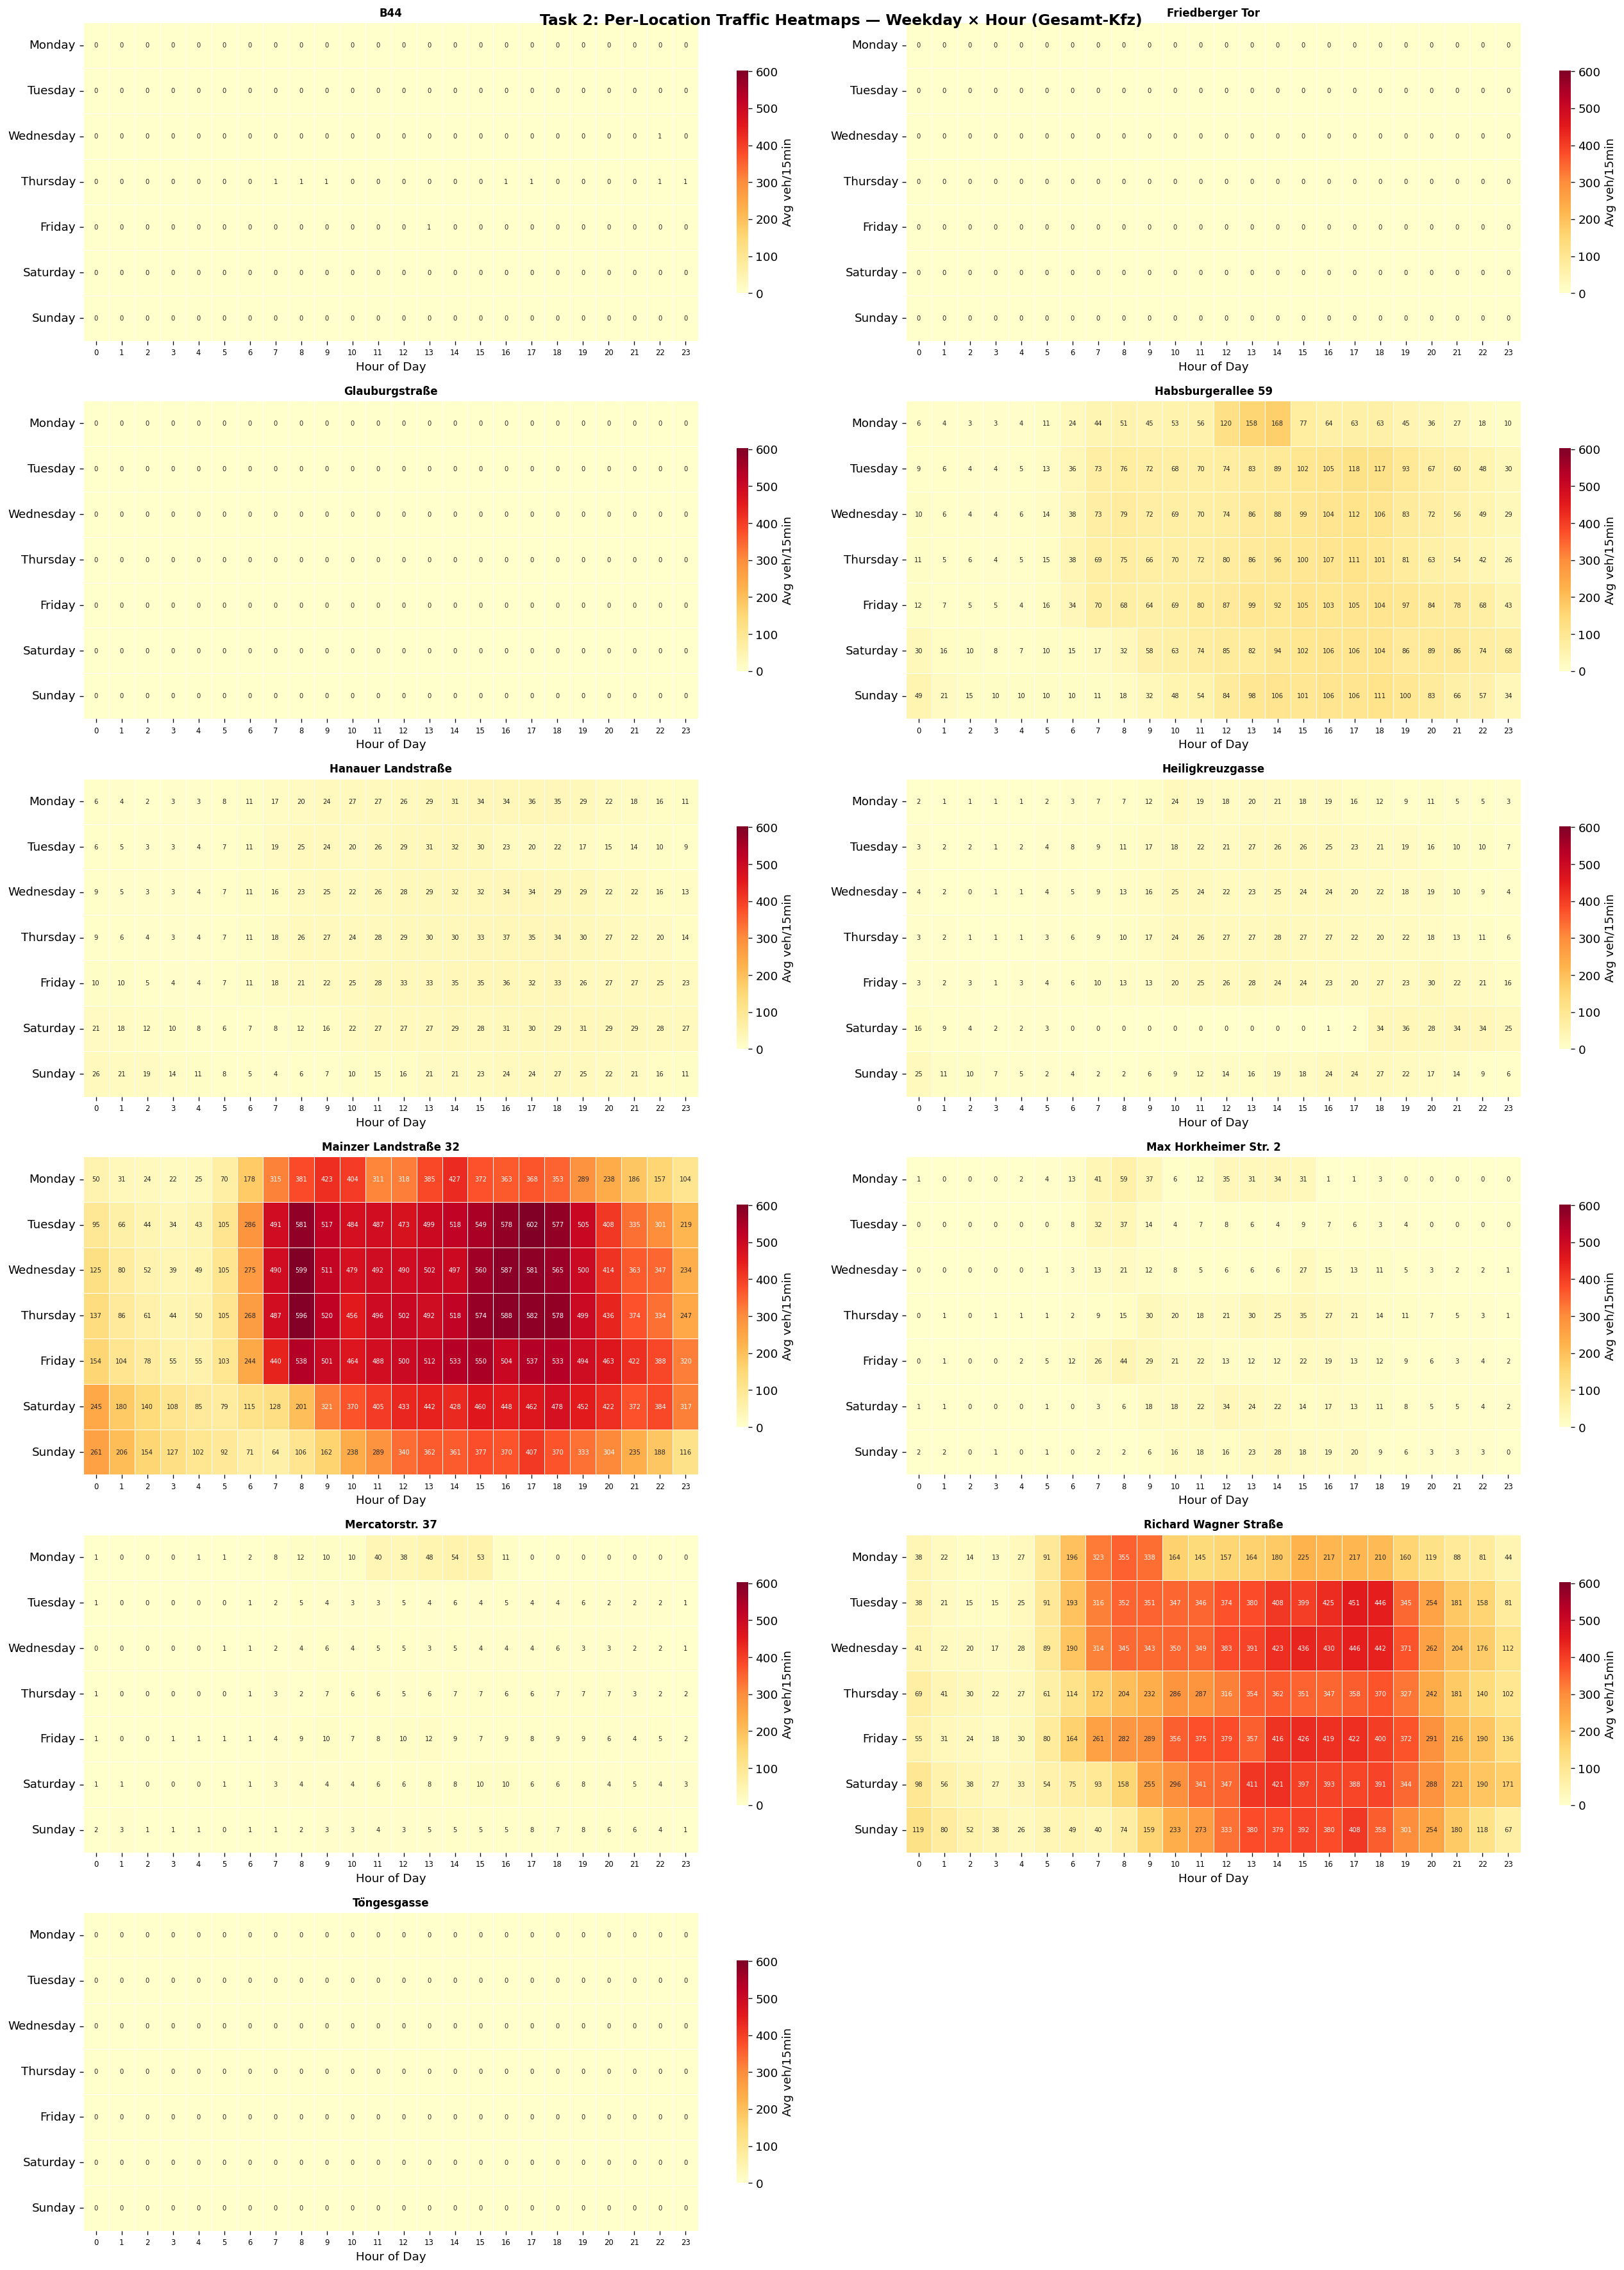

💾 Saved: task2_heatmaps_per_location.png


In [11]:
# ── Task 2-B: Per-location heatmaps (4 per row) ───────────────────────────────

locations = sorted(df_total['location'].unique())
n = len(locations)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()
fig.suptitle('Task 2: Per-Location Traffic Heatmaps — Weekday × Hour (Gesamt-Kfz)',
             fontsize=14, fontweight='bold')

# Compute global vmax for consistent colour scale
global_max = df_total.groupby(['location', 'weekday_name', 'hour'])['count'].mean().max()

for i, loc in enumerate(locations):
    ax = axes[i]
    sub = df_total[df_total['location'] == loc]
    pivot = (
        sub.groupby(['weekday_name', 'hour'])['count']
        .mean()
        .reset_index()
        .pivot(index='weekday_name', columns='hour', values='count')
        .reindex(DAY_ORDER)
    )
    sns.heatmap(
        pivot,
        ax=ax,
        cmap='YlOrRd',
        linewidths=0.3,
        linecolor='white',
        vmin=0,
        vmax=global_max,
        annot=True,
        fmt='.0f',
        annot_kws={'size': 6},
        cbar_kws={'label': 'Avg veh/15min', 'shrink': 0.7}
    )
    ax.set_title(loc, fontweight='bold', fontsize=10)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_heatmaps_per_location.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task2_heatmaps_per_location.png')

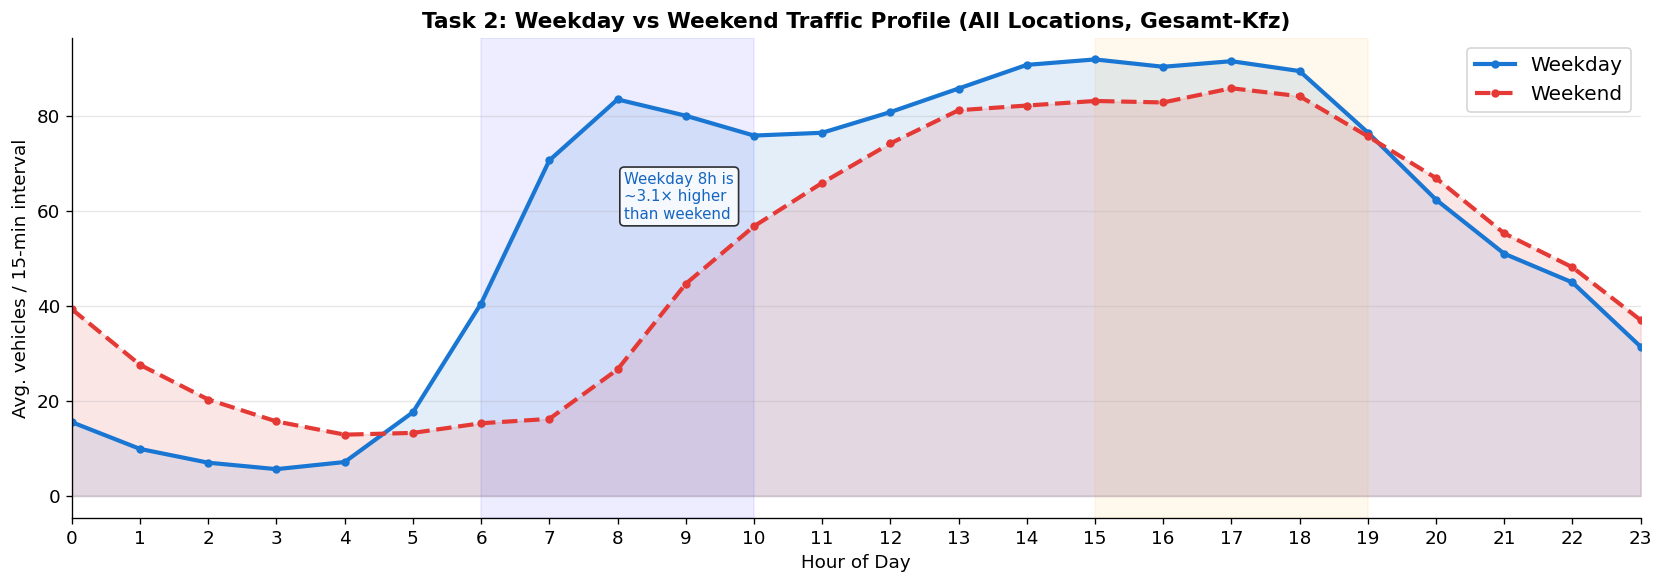

💾 Saved: task2_weekday_vs_weekend.png


In [13]:
# ── Task 2-C: Weekday vs Weekend comparison bar chart ─────────────────────────

df_total['day_type'] = df_total['weekday'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

hourly_daytype = (
    df_total
    .groupby(['day_type', 'hour'])['count']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for dtype, color, ls in [('Weekday', '#1976D2', '-'), ('Weekend', '#E53935', '--')]:
    sub = hourly_daytype[hourly_daytype['day_type'] == dtype]
    ax.plot(sub['hour'], sub['count'], color=color, linewidth=2.5,
            linestyle=ls, label=dtype, marker='o', markersize=4)
    ax.fill_between(sub['hour'], sub['count'], alpha=0.12, color=color)

ax.axvspan(6, 10, alpha=0.07, color='blue')
ax.axvspan(15, 19, alpha=0.07, color='orange')
ax.set_title('Task 2: Weekday vs Weekend Traffic Profile (All Locations, Gesamt-Kfz)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg. vehicles / 15-min interval')
ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=12)

# Annotate the typical morning rush difference
wkd = hourly_daytype[hourly_daytype['day_type'] == 'Weekday'].set_index('hour')['count']
wke = hourly_daytype[hourly_daytype['day_type'] == 'Weekend'].set_index('hour')['count']
ratio_8 = wkd.get(8, 1) / (wke.get(8, 1) + 0.001)
ax.text(8.1, wkd.get(8, 0) * 0.7,
        f'Weekday 8h is\n~{ratio_8:.1f}× higher\nthan weekend',
        fontsize=9, color='#1565C0',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_weekday_vs_weekend.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task2_weekday_vs_weekend.png')

In [14]:
# ── Task 2-D: Observations / Particularities ──────────────────────────────────

# Compute some stats to guide observations
by_day = df_total.groupby('weekday_name')['count'].mean().reindex(DAY_ORDER)
by_hour = df_total.groupby('hour')['count'].mean()

print('📊 Average traffic count per weekday (all locations, 15-min intervals):')
for d, v in by_day.items():
    bar = '█' * int(v / by_day.max() * 40)
    print(f'  {d:12s}: {v:5.1f}  {bar}')

print(f'\n  Busiest day  : {by_day.idxmax()} ({by_day.max():.1f} veh/15min avg)')
print(f'  Quietest day : {by_day.idxmin()} ({by_day.min():.1f} veh/15min avg)')

print('\n📊 Average traffic count per hour (all days, all locations):')
print(f'  Peak morning (6-10h) peak hour : {by_hour.loc[6:10].idxmax():02d}:00 ({by_hour.loc[6:10].max():.1f} veh/15min)')
print(f'  Peak evening (15-19h) peak hour: {by_hour.loc[15:19].idxmax():02d}:00 ({by_hour.loc[15:19].max():.1f} veh/15min)')
print(f'  Quietest hour                  : {by_hour.idxmin():02d}:00 ({by_hour.min():.1f} veh/15min)')

wkd_avg = df_total[df_total['weekday'] < 5]['count'].mean()
wke_avg = df_total[df_total['weekday'] >= 5]['count'].mean()
print(f'\n  Weekday avg : {wkd_avg:.1f} veh/15min')
print(f'  Weekend avg : {wke_avg:.1f} veh/15min')
print(f'  Weekday/Weekend ratio: {wkd_avg/wke_avg:.2f}x more traffic on weekdays')

📊 Average traffic count per weekday (all locations, 15-min intervals):
  Monday      :  47.4  █████████████████████████████
  Tuesday     :  55.3  ██████████████████████████████████
  Wednesday   :  62.6  ███████████████████████████████████████
  Thursday    :  59.6  █████████████████████████████████████
  Friday      :  63.7  ████████████████████████████████████████
  Saturday    :  55.4  ██████████████████████████████████
  Sunday      :  45.4  ████████████████████████████

  Busiest day  : Friday (63.7 veh/15min avg)
  Quietest day : Sunday (45.4 veh/15min avg)

📊 Average traffic count per hour (all days, all locations):
  Peak morning (6-10h) peak hour : 10:00 (70.6 veh/15min)
  Peak evening (15-19h) peak hour: 17:00 (89.9 veh/15min)
  Quietest hour                  : 03:00 (8.4 veh/15min)

  Weekday avg : 57.3 veh/15min
  Weekend avg : 50.4 veh/15min
  Weekday/Weekend ratio: 1.14x more traffic on weekdays


---
## Task 3 — Compare Measurement Sites: Most Congested Overall, Each Monday, Each Sunday

**Goal:** Rank all locations by total traffic. Find which site was most congested overall, on Mondays specifically, and on Sundays specifically.

> ⚠️ **Note on Monday/Sunday coverage:** Not all locations were measured on all Mondays/Sundays. Where a location has multiple Mondays/Sundays, counts are averaged per day. A coverage table is printed to show transparency.

In [15]:
# ── Task 3-A: Coverage table — which Mondays/Sundays per location ──────────────

df_total = df[df['vehicle_type'] == 'Gesamt-Kfz'].copy()

mon_sun = df_total[df_total['weekday'].isin([0, 6])].copy()  # 0=Mon, 6=Sun
mon_sun['day_label'] = mon_sun['weekday'].map({0: 'Monday', 6: 'Sunday'})

coverage = (
    mon_sun
    .groupby(['location', 'day_label'])['date']
    .apply(lambda x: sorted(str(d) for d in x.unique()))
    .reset_index()
)
coverage.columns = ['Location', 'Day Type', 'Dates Measured']
print('📅 Monday / Sunday coverage per location:')
coverage

📅 Monday / Sunday coverage per location:


,Location,Day Type,Dates Measured
0,B44,Monday,"[2024-09-09, 2024-09-16, 2024-09-23]"
1,B44,Sunday,"[2024-09-15, 2024-09-22]"
2,Friedberger Tor,Monday,"[2024-09-30, 2024-10-07]"
3,Friedberger Tor,Sunday,"[2024-09-29, 2024-10-06]"
4,Glauburgstraße,Monday,"[2024-10-14, 2024-10-21]"
5,Glauburgstraße,Sunday,"[2024-10-13, 2024-10-20]"
6,Habsburgerallee 59,Monday,"[2024-09-09, 2024-09-16, 2024-09-23]"
7,Habsburgerallee 59,Sunday,"[2024-09-15, 2024-09-22]"
8,Hanauer Landstraße,Monday,"[2024-10-14, 2024-10-21]"
9,Hanauer Landstraße,Sunday,"[2024-10-13, 2024-10-20]"


In [16]:
# ── Task 3-B: Overall congestion ranking ──────────────────────────────────────

# Total daily traffic = sum of all 96 15-min intervals per day, then avg across days
daily_totals = (
    df_total
    .groupby(['location', 'date'])['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'daily_total'})
)

overall_rank = (
    daily_totals
    .groupby('location')['daily_total']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'Avg Daily Total', 'sum': 'Grand Total', 'count': 'Days Measured'})
    .sort_values('Avg Daily Total', ascending=False)
    .reset_index()
)
overall_rank.index += 1  # rank from 1
overall_rank['Avg Daily Total'] = overall_rank['Avg Daily Total'].round(0).astype(int)
overall_rank['Grand Total'] = overall_rank['Grand Total'].astype(int)

print('🏆 Overall Congestion Ranking (by average daily vehicle count):')
overall_rank

🏆 Overall Congestion Ranking (by average daily vehicle count):


,location,Avg Daily Total,Grand Total,Days Measured
1,Mainzer Landstraße 32,30689,460340,15
2,Richard Wagner Straße,21137,295912,14
3,Habsburgerallee 59,5435,81532,15
4,Hanauer Landstraße,3735,56024,15
5,Heiligkreuzgasse,1219,18280,15
6,Max Horkheimer Str. 2,960,12484,13
7,Mercatorstr. 37,478,6693,14
8,B44,10,148,15
9,Friedberger Tor,0,0,14
10,Glauburgstraße,0,0,15


In [17]:
# ── Task 3-C: Monday ranking ──────────────────────────────────────────────────

monday_data = df_total[df_total['weekday'] == 0].copy()
monday_daily = (
    monday_data
    .groupby(['location', 'date'])['count']
    .sum()
    .reset_index()
)
monday_rank = (
    monday_daily
    .groupby('location')['count']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Avg Monday Total', 'count': 'Mondays Measured'})
    .sort_values('Avg Monday Total', ascending=False)
    .reset_index()
)
monday_rank.index += 1
monday_rank['Avg Monday Total'] = monday_rank['Avg Monday Total'].round(0).astype(int)

print('📅 Monday Congestion Ranking:')
monday_rank

📅 Monday Congestion Ranking:


,location,Avg Monday Total,Mondays Measured
1,Mainzer Landstraße 32,23185,3
2,Richard Wagner Straße,14348,2
3,Habsburgerallee 59,4613,3
4,Hanauer Landstraße,3795,2
5,Max Horkheimer Str. 2,1250,2
6,Mercatorstr. 37,1150,2
7,Heiligkreuzgasse,937,3
8,B44,1,3
9,Friedberger Tor,0,2
10,Glauburgstraße,0,2


In [18]:
# ── Task 3-D: Sunday ranking ──────────────────────────────────────────────────

sunday_data = df_total[df_total['weekday'] == 6].copy()
sunday_daily = (
    sunday_data
    .groupby(['location', 'date'])['count']
    .sum()
    .reset_index()
)
sunday_rank = (
    sunday_daily
    .groupby('location')['count']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Avg Sunday Total', 'count': 'Sundays Measured'})
    .sort_values('Avg Sunday Total', ascending=False)
    .reset_index()
)
sunday_rank.index += 1
sunday_rank['Avg Sunday Total'] = sunday_rank['Avg Sunday Total'].round(0).astype(int)

print('☀️ Sunday Congestion Ranking:')
sunday_rank

☀️ Sunday Congestion Ranking:


,location,Avg Sunday Total,Sundays Measured
1,Mainzer Landstraße 32,22537,2
2,Richard Wagner Straße,18923,2
3,Habsburgerallee 59,5346,2
4,Hanauer Landstraße,3178,2
5,Heiligkreuzgasse,1224,2
6,Max Horkheimer Str. 2,792,2
7,Mercatorstr. 37,344,2
8,Glauburgstraße,0,2
9,Friedberger Tor,0,2
10,B44,0,2


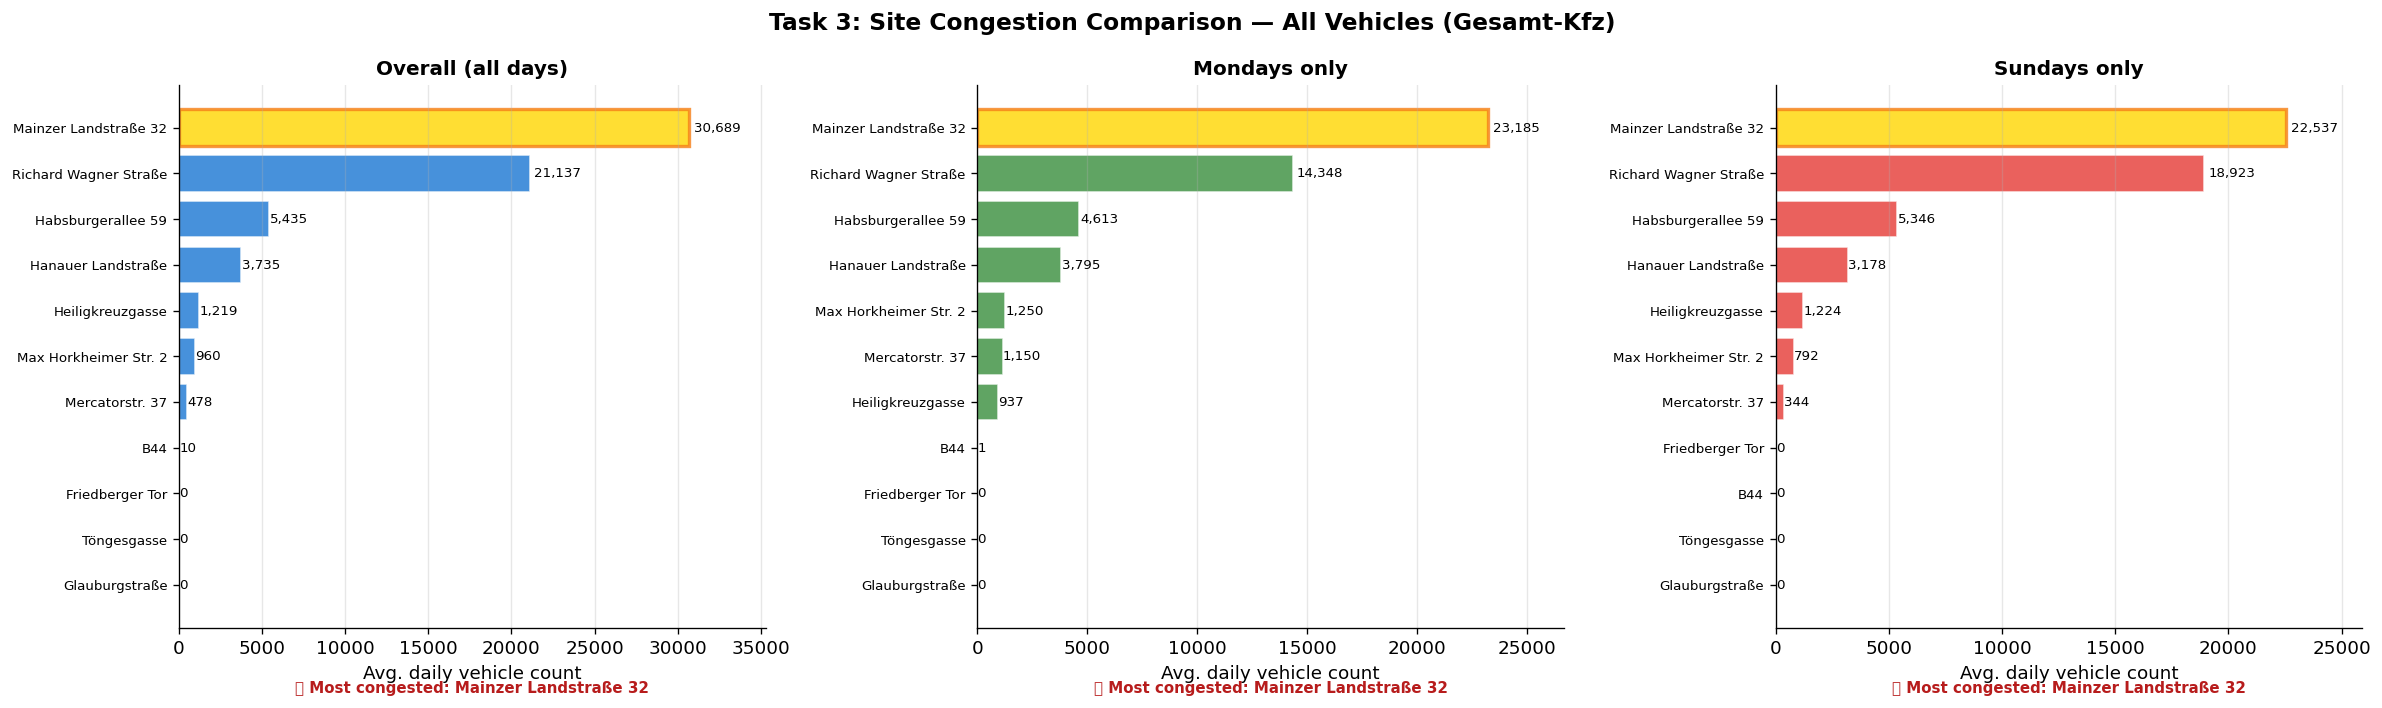

💾 Saved: task3_site_comparison.png


In [19]:
# ── Task 3-E: Visual comparison — horizontal bar charts ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Task 3: Site Congestion Comparison — All Vehicles (Gesamt-Kfz)',
             fontsize=14, fontweight='bold')

datasets = [
    (overall_rank, 'Avg Daily Total', 'Overall (all days)', '#1976D2'),
    (monday_rank,  'Avg Monday Total', 'Mondays only',       '#388E3C'),
    (sunday_rank,  'Avg Sunday Total', 'Sundays only',        '#E53935'),
]

for ax, (rank_df, col, title, color) in zip(axes, datasets):
    # Sort ascending for horizontal bar (highest at top)
    sorted_df = rank_df.sort_values(col, ascending=True)
    bars = ax.barh(sorted_df['location'], sorted_df[col],
                   color=color, alpha=0.8, edgecolor='white')

    # Highlight top bar
    bars[-1].set_color('#FFD600')
    bars[-1].set_edgecolor('#F57F17')
    bars[-1].set_linewidth(2)

    # Value labels
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', fontsize=8)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Avg. daily vehicle count')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, rank_df[col].max() * 1.15)

    # Mark winner
    winner = rank_df.loc[rank_df[col].idxmax(), 'location']
    ax.text(0.5, -0.12, f'🏆 Most congested: {winner}',
            transform=ax.transAxes, ha='center', fontsize=9,
            color='#B71C1C', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task3_site_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task3_site_comparison.png')

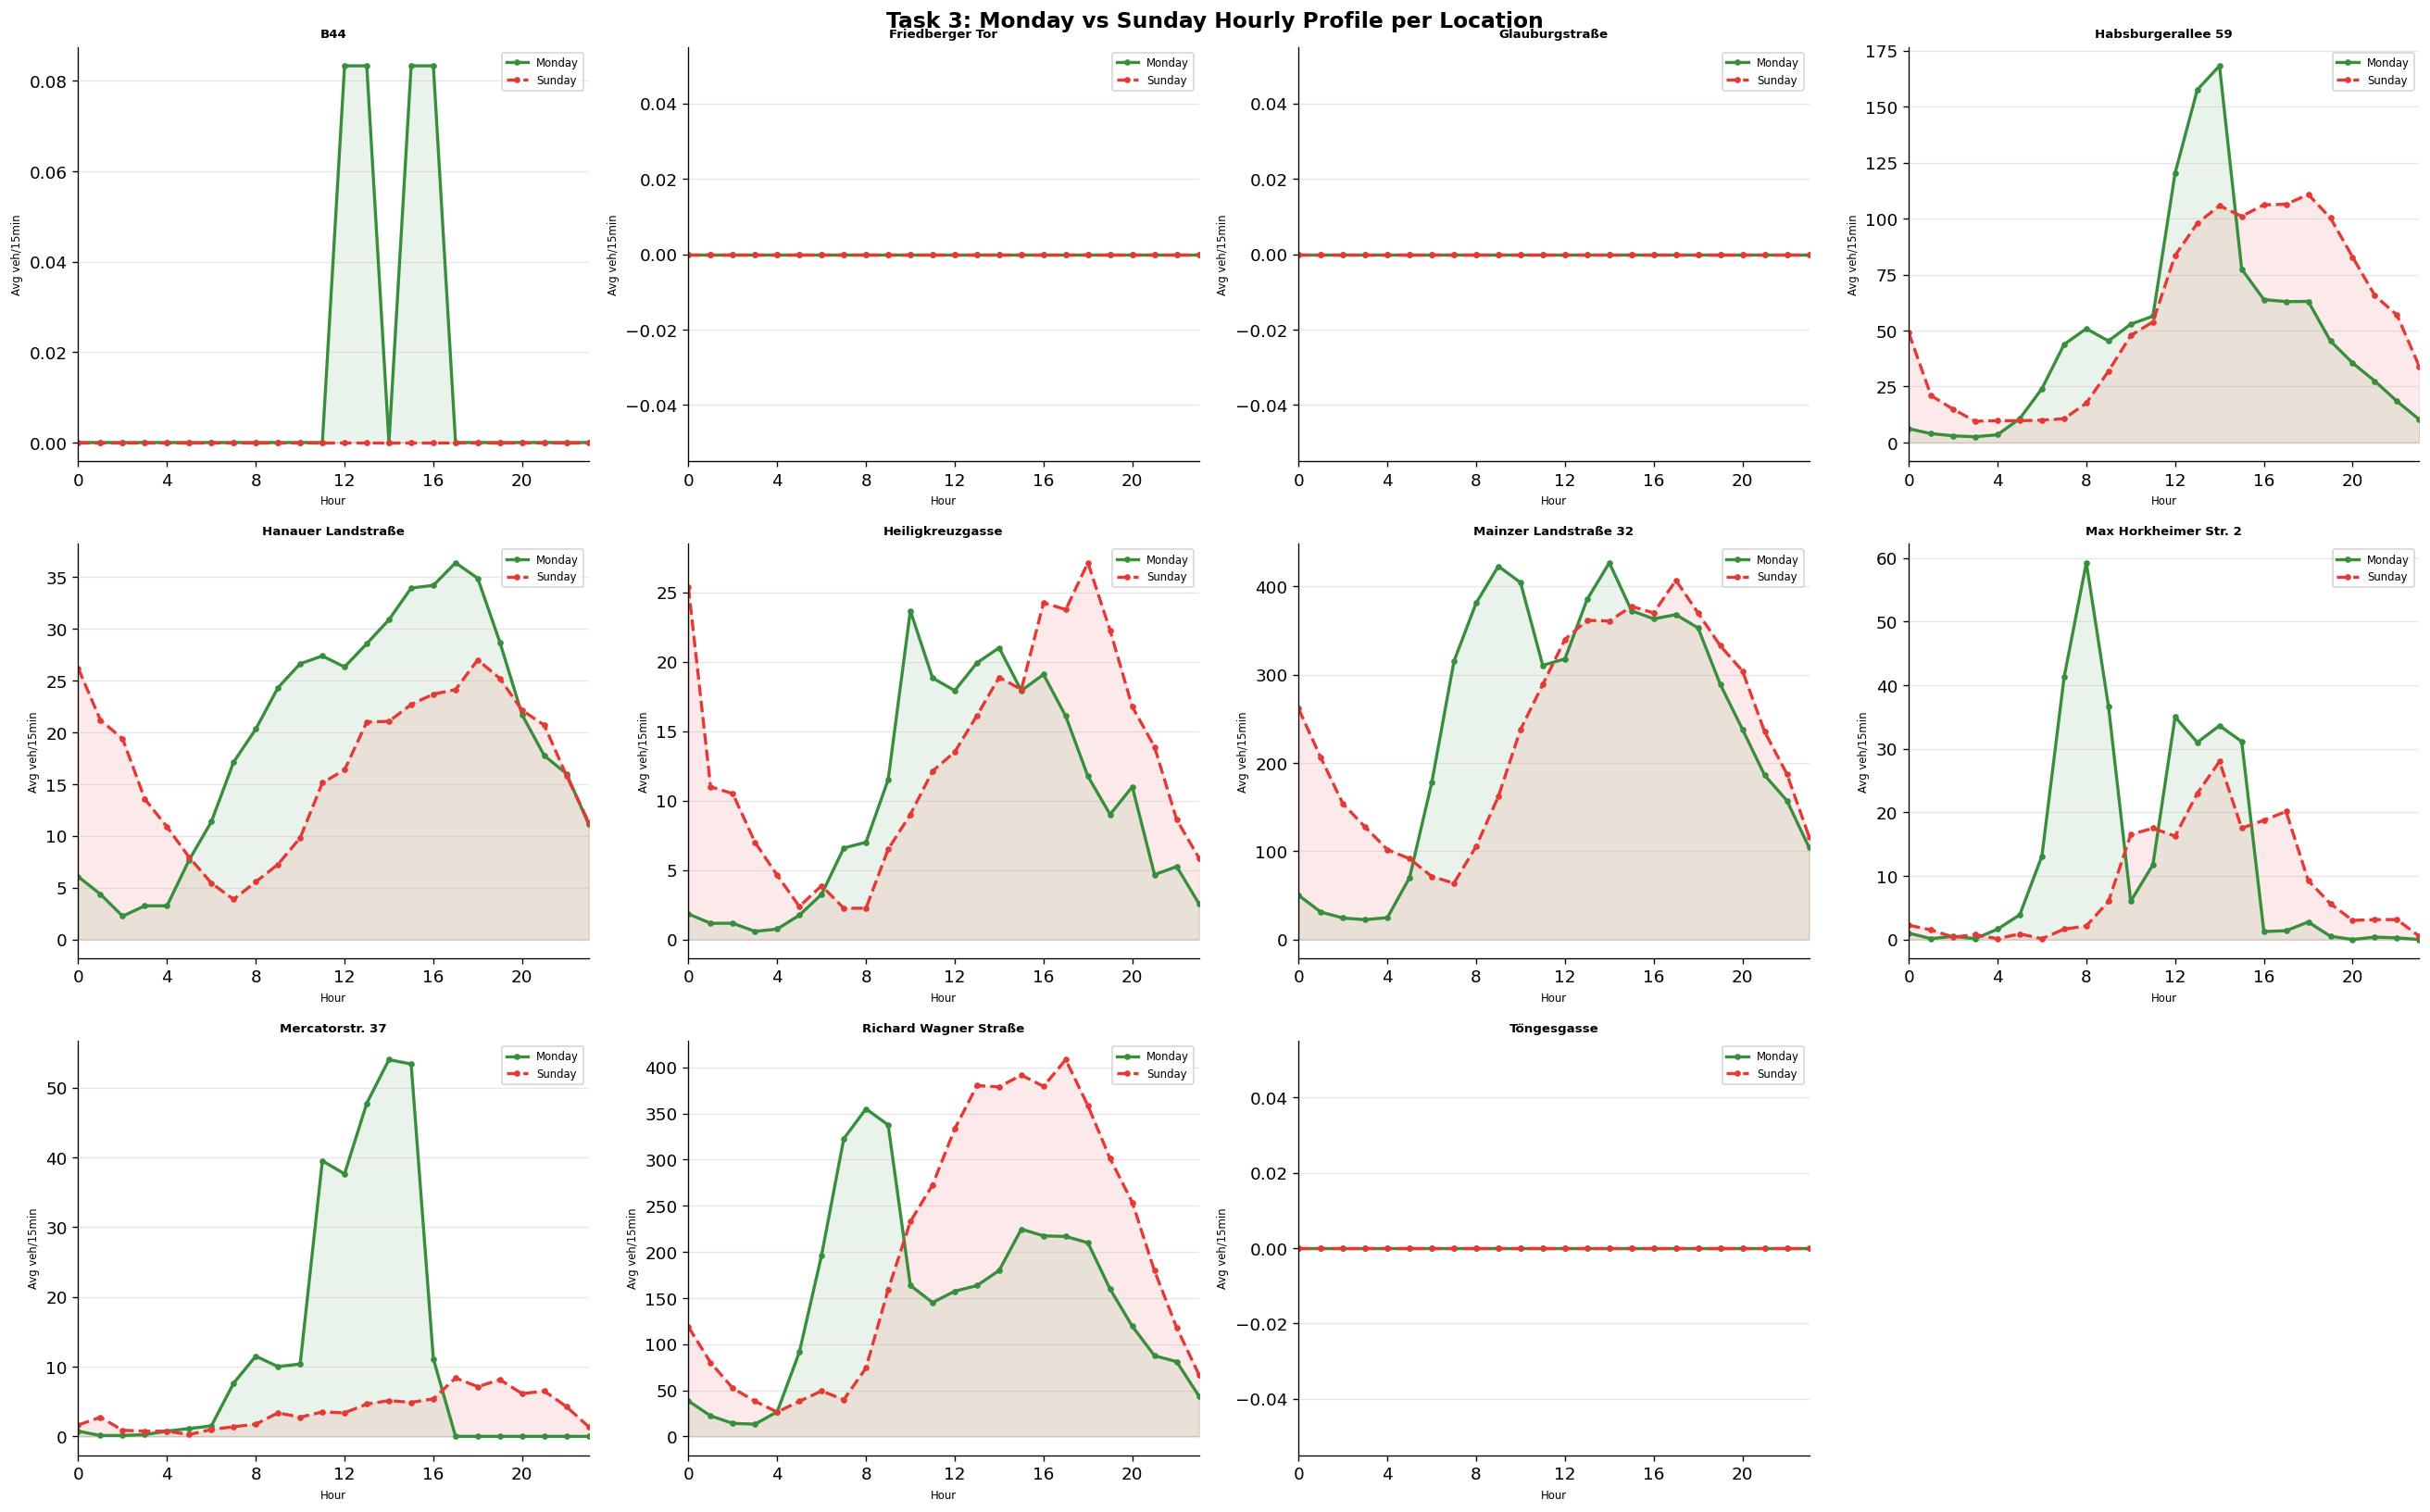

💾 Saved: task3_monday_vs_sunday_profiles.png


In [20]:
# ── Task 3-F: Congestion profile per location on Mondays vs Sundays ───────────

locations = sorted(df_total['location'].unique())
fig, axes = plt.subplots(4, 4, figsize=(22, 18), sharey=False)
axes = axes.flatten()
fig.suptitle('Task 3: Monday vs Sunday Hourly Profile per Location',
             fontsize=14, fontweight='bold')

for i, loc in enumerate(locations):
    ax = axes[i]
    sub = df_total[df_total['location'] == loc]

    for wd, label, color, ls in [(0, 'Monday', '#388E3C', '-'), (6, 'Sunday', '#E53935', '--')]:
        day_sub = sub[sub['weekday'] == wd]
        if day_sub.empty:
            continue
        hourly = day_sub.groupby('hour')['count'].mean()
        ax.plot(hourly.index, hourly.values, color=color, linewidth=2,
                linestyle=ls, label=label, marker='o', markersize=3)
        ax.fill_between(hourly.index, hourly.values, alpha=0.1, color=color)

    ax.set_title(loc, fontweight='bold', fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.set_xlim(0, 23)
    ax.set_xlabel('Hour', fontsize=7)
    ax.set_ylabel('Avg veh/15min', fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task3_monday_vs_sunday_profiles.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Saved: task3_monday_vs_sunday_profiles.png')

In [21]:
# ── Task 3-G: Final summary ───────────────────────────────────────────────────

top_overall = overall_rank.loc[1, 'location']
top_monday  = monday_rank.loc[1, 'location']  if not monday_rank.empty else 'N/A'
top_sunday  = sunday_rank.loc[1, 'location']  if not sunday_rank.empty else 'N/A'

print('=' * 60)
print('  TASK 3 — FINAL ANSWERS')
print('=' * 60)
print(f'\n  🏆 Most congested site OVERALL  : {top_overall}')
print(f'  📅 Most congested site MONDAYS  : {top_monday}')
print(f'  ☀️  Most congested site SUNDAYS  : {top_sunday}')
print()

# Monday coverage note
locs_with_mondays = monday_rank['location'].tolist()
locs_without_mondays = [l for l in sorted(df_total['location'].unique()) if l not in locs_with_mondays]
if locs_without_mondays:
    print(f'  ⚠️  Locations WITH NO Monday data: {locs_without_mondays}')
    print(f'     → For a complete Monday comparison you may need the full')
    print(f'       Mobilithek dataset: https://mobilithek.info/offers/842371963004272640')

print('=' * 60)

  TASK 3 — FINAL ANSWERS

  🏆 Most congested site OVERALL  : Mainzer Landstraße 32
  📅 Most congested site MONDAYS  : Mainzer Landstraße 32
  ☀️  Most congested site SUNDAYS  : Mainzer Landstraße 32



---
## Summary of Outputs

| File | Description |
|------|-------------|
| `task1_daily_profiles.png` | 6-panel plot: daily profile per vehicle type |
| `task1_combined_overview.png` | All types on one chart |
| `task1_per_location_profiles.png` | Daily profile for each measurement site |
| `task2_heatmap_global.png` | Global heatmap: weekday × hour |
| `task2_heatmaps_per_location.png` | Individual heatmap per site |
| `task2_weekday_vs_weekend.png` | Weekday vs weekend line comparison |
| `task3_site_comparison.png` | Horizontal bar: overall / Monday / Sunday ranking |
| `task3_monday_vs_sunday_profiles.png` | Mon vs Sun hourly profile per site |

---
*Data source: Mobilithek — Automatisierte Verkehrsflusszählung Frankfurt am Main (Open Data)*